SISTECH 2026 — MLOps Hands-On 1
## Membangun Fondasi Sistem Prediksi **Risk Score** (Chicago Crimes)

Selamat datang di Hands-On pertama **Machine Learning Operations** SISTECH 2026! 🎉

Notebook ini adalah **tutorial referensi**. Tugasnya memandu kalian mengubah data
kejahatan mentah menjadi sebuah **dataset fitur + label** yang siap dimodelkan di Hands-On 2.
Target akhirnya adalah sebuah **Risk Score (0–100)** yang menggambarkan tingkat risiko
sebuah lokasi pada waktu tertentu, berdasarkan pola kejahatan historis.

**Alur yang akan kita lalui:**
1. Setup & load dataset (Chicago Crimes)
2. Pembersihan data
3. **EDA** — memahami pola kejahatan lintas *waktu* dan *lokasi*
4. **Feature Engineering** — temporal (cyclical encoding) & spasial (grid aggregation)
5. **Pseudo-Labeling** — severity scoring + temporal decay + agregasi spasial → Risk Score
6. Menyusun & menyimpan dataset akhir (CSV/Parquet)

> 🧭 **Prinsip inti:** *data as foundation.* Model secanggih apa pun tidak berguna bila
> dibangun di atas data yang buruk. Tahap ini bukan sekadar "persiapan" — ini penentu
> keberhasilan seluruh sistem.

---

> ## ⚠️ Cara memakai notebook ini — BACA DULU
>
> Notebook ini **sengaja dibuat sebagai versi paling sederhana (naif).** Ia berjalan
> dari atas sampai bawah dan menghasilkan dataset akhir, **tapi banyak keputusannya
> sengaja dibuat seadanya** supaya kalian bisa melihat *mekanismenya bekerja* — bukan
> supaya kalian menyalinnya bulat-bulat.
>
> Sepanjang notebook kalian akan menemukan dua jenis blok:
> - 🔧 **Versi Sederhana (Baseline)** — kode yang berfungsi tapi jelas belum optimal.
> - 🙋 **Giliran Kalian** — di sinilah kalian mengambil alih: mengembangkan, mengganti,
>   atau memperbaiki versi sederhana tadi, lalu **menjustifikasinya di laporan**.
>
> Bagian yang paling dinilai (severity scoring & pemodelan relevansi waktu–lokasi) justru
> yang paling "mentah" di sini. Itu disengaja. **Nilai kalian datang dari seberapa jauh kalian
> mengembangkannya, bukan dari menjalankan notebook ini apa adanya.**

# 0. Installation & Setup

Kita hanya butuh stack data science standar: `pandas`, `numpy`, `matplotlib`, `seaborn`,
`scikit-learn`, dan `gdown` (untuk mengunduh dataset dari Google Drive).

In [1]:
# Jalankan sekali saja (di Colab biasanya sudah tersedia, kecuali gdown & pyarrow)
!pip install -q gdown pyarrow seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print("Setup selesai ✅")

Setup selesai ✅


# 1. Download & Import Dataset

Kita memakai dataset **Chicago Crimes**. Kolom-kolom penting untuk kita:
`Date`, `Primary Type`, `Description`, `Latitude`, `Longitude`, `Arrest`, `Location Description`.

> 📦 **Dataset asli sangat besar** (jutaan baris). Sesuai anjuran di dokumen, kita akan
> **mengambil subset** agar komputasi ringan. **Jelaskan pilihan subset kalian di laporan.**

In [3]:
import gdown

# File ID dari link dataset pada dokumen hands-on
FILE_ID = "12K13Az7ynV3ZVimSARImgggnbDbVqjk_"
OUTPUT  = "chicago_crimes.csv"

gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_
From (redirected): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_&confirm=t&uuid=8420844a-46ee-4a65-8ec2-589dc11281aa
To: /content/chicago_crimes.csv
100%|██████████| 2.37G/2.37G [00:44<00:00, 53.7MB/s]


'chicago_crimes.csv'

In [4]:
# Hanya baca kolom yang kita butuhkan -> hemat memori
usecols = ["ID", "Date", "Primary Type", "Description",
           "Location Description", "Arrest", "Latitude", "Longitude", "Year"]

df = pd.read_csv(OUTPUT, usecols=lambda c: c in usecols)
print("Shape mentah:", df.shape)
df.head()

Shape mentah: (8534663, 9)


,ID,Date,Primary Type,Description,Location Description,Arrest,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,THEFT,$500 AND UNDER,STREET,False,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,BATTERY,SIMPLE,STREET,False,2026,41.884097,-87.675228
3,14163678,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,2026,41.977655,-87.697553
4,14164937,04/11/2026 12:00:00 AM,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,2026,41.954538,-87.651148


### 🙋 Giliran Kalian — Tentukan Subset

Dataset ini bisa sangat besar. Contoh strategi subset (pilih & **justifikasi**):
- **Rentang tahun** tertentu (mis. 3 tahun terakhir agar pola relevan dengan kondisi terkini).
- **Area** tertentu (mis. satu *District* atau bounding box tertentu).

Di bawah ini kita contohkan subset **3 tahun terakhir** yang tersedia di data. Ini keputusan
desain pertama kalian — ukuran & cakupan subset memengaruhi seluruh analisis berikutnya.

In [5]:
n_years = 3

if "Year" in df.columns:
    last_year = int(df["Year"].max())
    df = df[df["Year"] >= last_year - (n_years - 1)].copy()
    print(f"Subset {last_year - (n_years - 1)}-{last_year}. Shape:", df.shape)

Subset 2024-2026. Shape: (553919, 9)


Subset yang digunakan:
**3 Tahun terakhir yang tersedia di dataset (2024 - 2026)**.

**Justifikasi:**

1. **Rentang tahun dipilih, bukan area/district**, supaya variasi spasial (hotspot vs area aman) tetap utuh untuk dianalisis. Krusial karena Risk Score sangat bergantung pada sinyal spasial yang kaya. Membatasi ke satu area/district justru menghilangkan variasi itu sebelum sempat dianalisis.

2.  **3 tahun** dipilih supaya pola musiman (`month`, `day-of-week`) tidak bias ke satu musim / periode tertentu, sekaligus menggunakan data paling terkini yang tersedia supaya relevan dengan kondisi kejahatan Chicago saat ini.

- Jumlah baris setelah cleaning: **(553919, 9)**.

# 2. Pembersihan Data

Langkah cleaning ini kita sediakan **cukup lengkap** — karena bukan fokus penilaian
hands-on ini, dan kalian butuh data yang bersih sebagai titik awal yang benar. Yang kita lakukan:
- **Parse kolom `Date`** menjadi tipe datetime (format Chicago: `MM/DD/YYYY HH:MM:SS AM/PM`).
- **Buang baris tanpa koordinat / tanggal** — tanpa `Latitude`/`Longitude`, sebuah kejadian
  tidak bisa dipetakan ke grid spasial.
- **Filter koordinat di luar bounding box Chicago** (menyingkirkan koordinat rusak / 0,0).
- Turunkan kolom waktu dasar: `hour`, `dow` (day-of-week), `month`.

In [6]:
# Parse tanggal
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
# Buang baris tanpa koordinat / tanpa tanggal valid
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()

# Bounding box kasar wilayah Chicago -> singkirkan koordinat rusak
df = df[df["Latitude"].between(41.60, 42.05) &
        df["Longitude"].between(-87.95, -87.50)].copy()

# Fitur waktu dasar
df["hour"]  = df["Datetime"].dt.hour
df["dow"]   = df["Datetime"].dt.dayofweek        # 0 = Senin ... 6 = Minggu
df["month"] = df["Datetime"].dt.month

print(f"Dibuang {before - len(df):,} baris. Shape bersih: {df.shape}")
df[["Datetime", "Primary Type", "Description", "Latitude", "Longitude", "hour", "dow"]].head()

Dibuang 3,023 baris. Shape bersih: (550896, 13)


,Datetime,Primary Type,Description,Latitude,Longitude,hour,dow
0,2026-04-11,THEFT,$500 AND UNDER,41.801025,-87.652621,0,5
2,2026-04-11,BATTERY,SIMPLE,41.884097,-87.675228,0,5
3,2026-04-11,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,41.977655,-87.697553,0,5
4,2026-04-11,THEFT,THEFT FROM MOTOR VEHICLE,41.954538,-87.651148,0,5
5,2026-04-11,BATTERY,SIMPLE,41.951894,-87.747276,0,5


# 3. Exploratory Data Analysis (EDA)

Tujuan EDA di sini: membangun **intuisi** tentang **kapan** dan **di mana** kejahatan
paling sering terjadi. Intuisi inilah yang nanti memandu keputusan feature engineering
dan pseudo-labeling.

Kita tunjukkan **beberapa contoh dasar** di bawah. Anggap ini titik awal — EDA yang baik
menggali lebih jauh dari sekadar menampilkan grafik.

## 3.1 Jenis Kejahatan Paling Umum

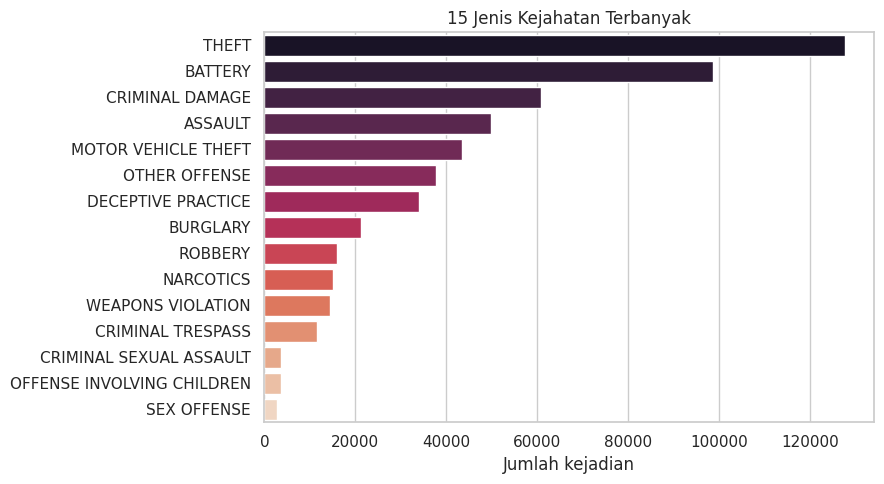

In [7]:
top_types = df["Primary Type"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_types.values, y=top_types.index, hue=top_types.index,
            palette="rocket", legend=False)
plt.title("15 Jenis Kejahatan Terbanyak")
plt.xlabel("Jumlah kejadian"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 3.2 Pola Temporal — Jam, Hari, Bulan

Perhatikan baik-baik pola per **jam** dan per **hari**. Pola inilah yang membuat fitur
temporal menjadi penting.

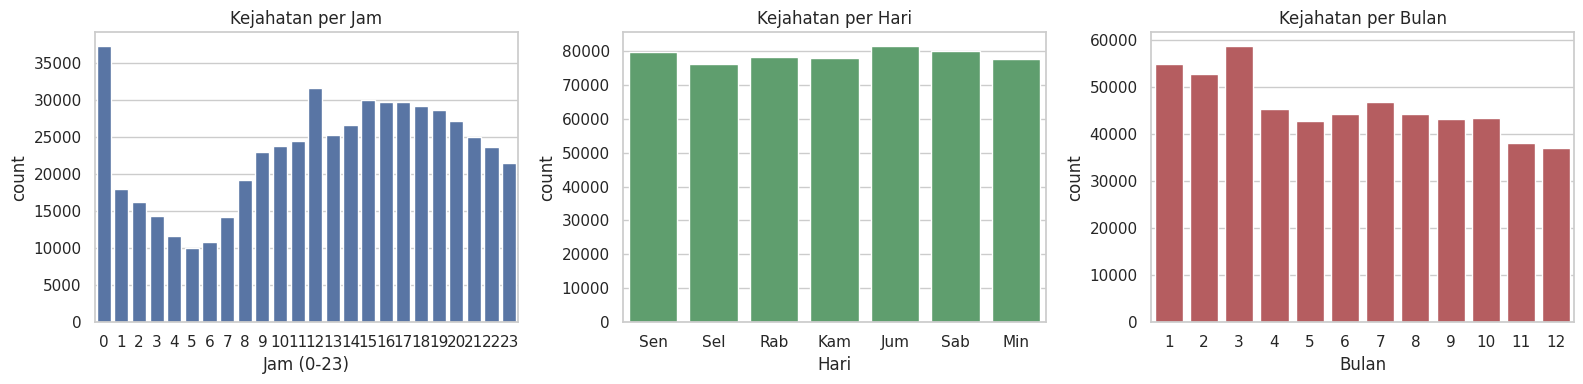

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Per jam
sns.countplot(x="hour", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Kejahatan per Jam"); axes[0].set_xlabel("Jam (0-23)")

# Per hari dalam seminggu
labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
sns.countplot(x="dow", data=df, order=[0,1,2,3,4,5,6], ax=axes[1], color="#55A868")
axes[1].set_title("Kejahatan per Hari"); axes[1].set_xlabel("Hari")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(labels_dow)

# Per bulan
sns.countplot(x="month", data=df, ax=axes[2], color="#C44E52")
axes[2].set_title("Kejahatan per Bulan"); axes[2].set_xlabel("Bulan")

plt.tight_layout(); plt.show()

## 3.3 Pola Spasial — Hotspot

Sebaran koordinat memperlihatkan **konsentrasi** kejahatan. `hexbin` cocok untuk
menunjukkan kepadatan tanpa terganggu jutaan titik yang saling menimpa.

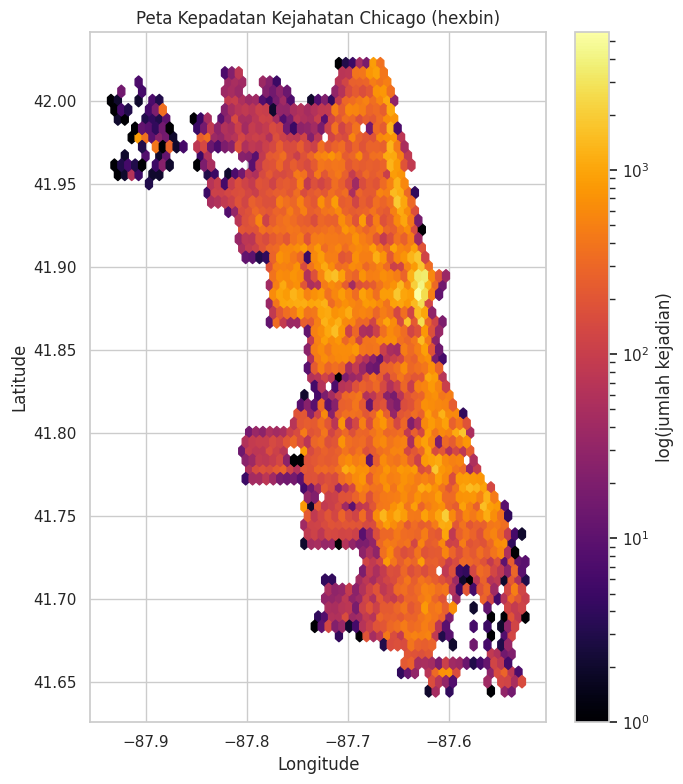

In [9]:
plt.figure(figsize=(7, 8))
hb = plt.hexbin(df["Longitude"], df["Latitude"], gridsize=60,
                cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, label="log(jumlah kejadian)")
plt.title("Peta Kepadatan Kejahatan Chicago (hexbin)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

### 🙋 Giliran Kalian — Gali Lebih Dalam

EDA di atas baru permukaan. Beberapa arah eksplorasi yang bisa **menemukan pola yang
belum terlihat** (dan nanti membantu kalian merancang fitur):
- Bagaimana pola **jam berbeda antara akhir pekan vs hari kerja**? (coba pisahkan)
- Apakah **jenis kejahatan tertentu** punya pola waktu/lokasi yang khas?
- Adakah **interaksi** antara dua dimensi (mis. hari × jam) yang tak terlihat bila dilihat terpisah?

> 📝 Tuliskan **pola paling menonjol** dari data kalian di laporan. Insight ini yang
> menjustifikasi kenapa kita butuh fitur temporal *dan* spasial.

## 3.4 Pola Jam - Akhir Pekan vs Hari Kerja

Di sini saya pisahkan **hari kerja** vs **akhir pekan** untuk melihat apakah jam sibuk kejahatannya bergeser tergantung dengan jenis harinya.

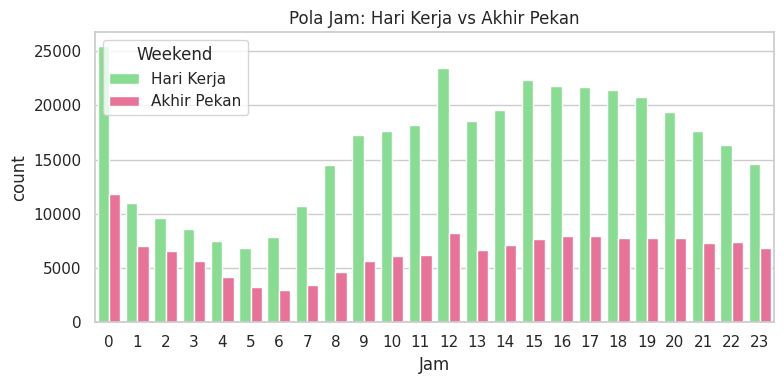

In [10]:
df["is_weekend"] = df["dow"].isin([5, 6])

plt.figure(figsize=(8, 4))
sns.countplot(x="hour", hue="is_weekend", data=df, palette=["#7AEB89", "#FC6091"])
plt.title("Pola Jam: Hari Kerja vs Akhir Pekan")
plt.xlabel("Jam"); plt.legend(title="Weekend", labels=["Hari Kerja", "Akhir Pekan"])
plt.tight_layout(); plt.show()

## 3.5 Pola Waktu - Per Jenis Kejahatan

Di sini saya bandingkan distribusi jam untuk 5 jenis kejahatan terbanyak, untuk melihat apakah pola waktu ini cukup berbeda.

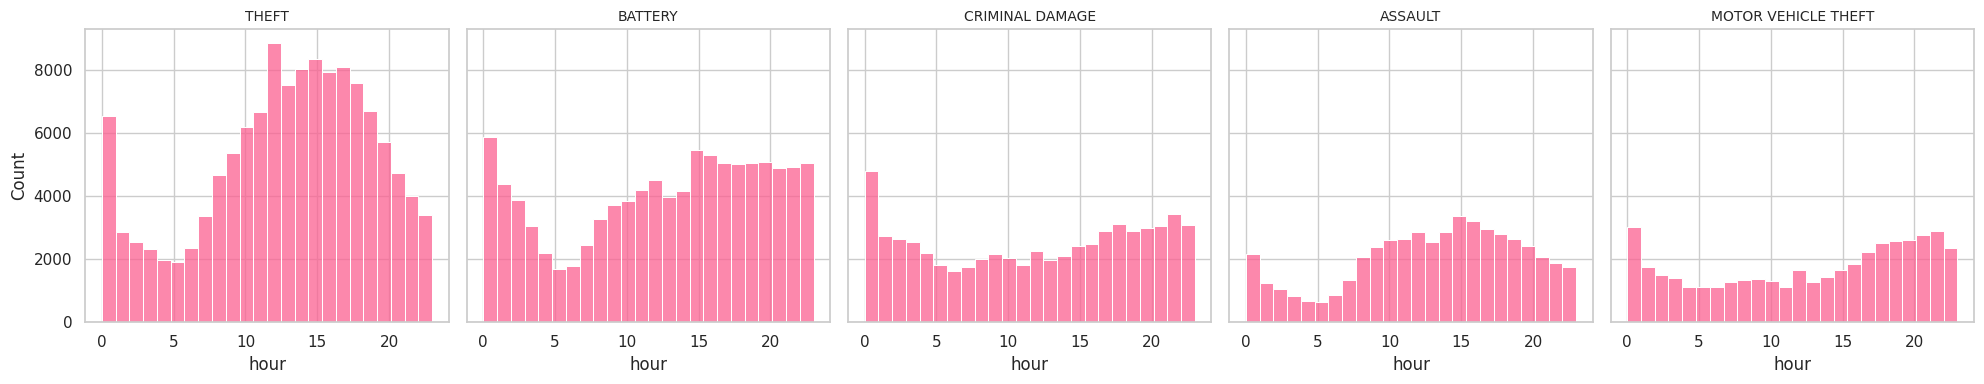

In [11]:
top5_types = df["Primary Type"].value_counts().head(5).index

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, crime in zip(axes, top5_types):
    sns.histplot(df[df["Primary Type"] == crime]["hour"], bins=24, ax=ax, color="#FC6091")
    ax.set_title(crime, fontsize=10)
plt.tight_layout(); plt.show()

## 3.6 Pola Interaksi Hari x Jam

Heatmap di bawah menunjukkan jumlah kejadian untuk tiap kombinasi hari x jam.

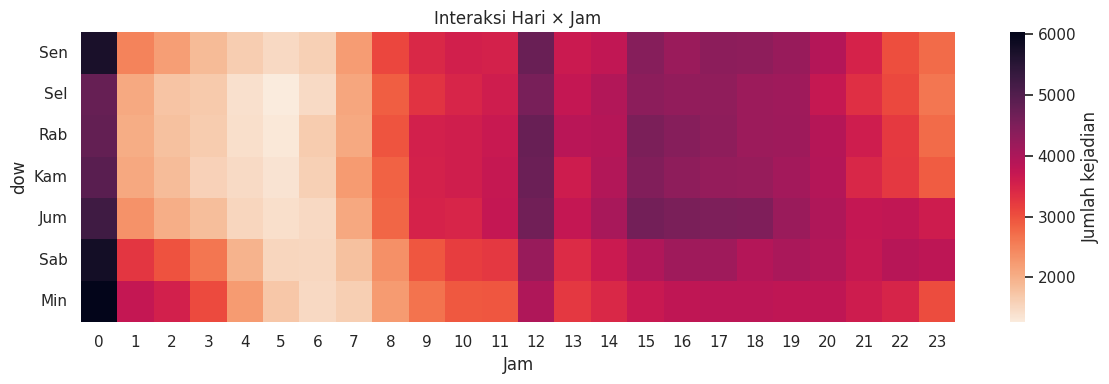

In [12]:
pivot = df.pivot_table(index="dow", columns="hour", values="ID", aggfunc="count")

plt.figure(figsize=(12, 4))
sns.heatmap(pivot, cmap="rocket_r", cbar_kws={"label": "Jumlah kejadian"})
plt.yticks(np.arange(7) + 0.5, ["Sen","Sel","Rab","Kam","Jum","Sab","Min"], rotation=0)
plt.title("Interaksi Hari × Jam")
plt.xlabel("Jam"); plt.tight_layout(); plt.show()

### Verifikasi Dugaan Artefak Pencatatan Waktu

Lonjakan tajam di jam 0 dan jam 12 pada grafik-grafik sebelumnya **mencurigakan** karena jika waktu kejadian benar-benar natural, seharusnya tidak ada satu jam yang jauh lebih tinggi dibanding jam-jam di sekitarnya secara konsisten.

Dugaan: ini adalah **artefak pencatatan**. saat waktu kejadian tidak diketahui pasti oleh petugas /  pelapor, sistem kemungkinan mencatat waktu yang dibulatkan ke jam penuh (`00:00` atau `12:00`) sebagai default, bukan waktu kejadian yang sesungguhnya.

Untuk membuktikan ini, saya coba untuk cek distribusi menit pada baris-baris yang jamnya tepat 0 dan 12. Jika waktu kejadian benar-benar presisi / acak, distribusi menit (0-59) seharusnya tersebar relatif merata. Jika sebaliknya menit `:00` muncul jauh lebih sering daripada menit lain, artinya itu bukti kuat bahwa waktu-waktu tersebut memang dibulatkan, bukan dicatat secara presisi.

In [13]:
print(df[df["hour"] == 0]["Datetime"].dt.minute.value_counts().head())
print(df[df["hour"] == 12]["Datetime"].dt.minute.value_counts().head())

Datetime
0     19529
1      3650
30     2317
15      730
45      590
Name: count, dtype: int64
Datetime
0     12419
30     3296
45     1128
15     1104
20      799
Name: count, dtype: int64


Hasil ini mengonfirmasi dugaan saya yaitu menit `:00` muncul jauh lebih dominan dibanding menit lain yang tersebar relatif merata (ratusan hingga sekitar seribu kejadian per menit). Jika waktu kejadian benar-benar presisi dan acak, seharusnya tidak ada satu menit tertentu yang menonjol setajam ini, apalagi persis di menit bulat (`:00`).

**Kesimpulan:** baris-baris dengan `hour == 0` atau `hour == 12` dan menit persis `:00`
kemungkinan besar adalah kejadian yang **waktu sebenarnya tidak diketahui**, lalu dicatat dengan waktu default /dibulatkan. Ini perlu ditangani sebelum lanjut ke feature engineering & pseudo-labeling, karena jika dibiarkan, Risk Score bisa salah menganggap jam 0 dan 12 sebagai jam yang jauh lebih berisiko.

## 3.7 Dampak Artefak Pencatatan Waktu terhadap Pola Jam

Setelah dikonfirmasi bahwa waktu `:00` di jam 0 dan 12 kemungkinan besar adalah artefak, perlu tahu seberapa besar dampaknya terhadap keseluruhan pola jam.

Apakah cukup
signifikan untuk mengubah kesimpulan EDA, atau cuma sedikit dan bisa diabaikan.

Baris difilter dengan flag `time_likely_imprecise` (jam 0 atau 12, dengan menit dan detik persis 0 supaya tidak salah membuang kejadian yang memang betul terjadi tepat
di jam tersebut dengan presisi menit / detik lain). Lalu saya bandingkan pola jam sebelum vs sesudah baris ini dikeluarkan.

Baris dengan waktu kemungkinan tidak presisi: 5.80%


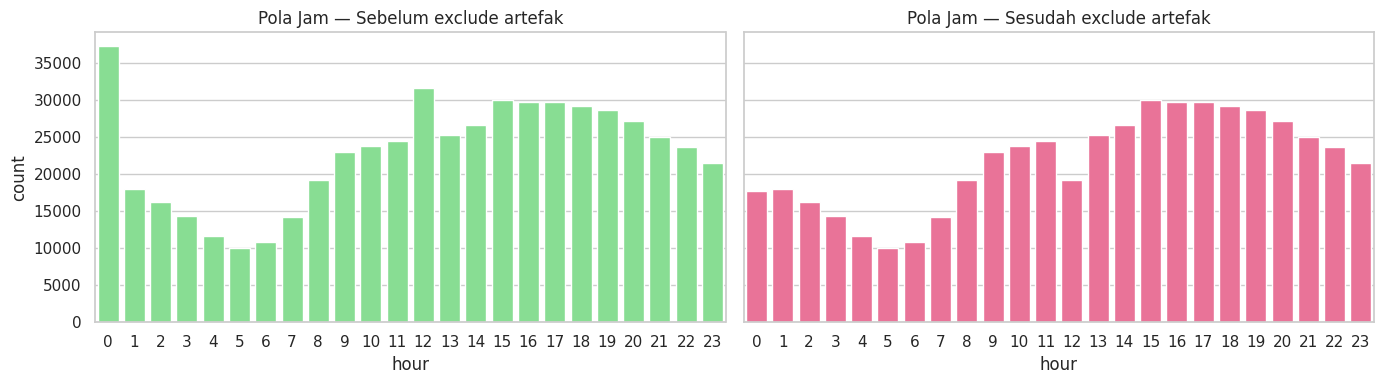

In [14]:
# Flag baris yang kemungkinan waktu-nya "dibulatkan" (menit=0 & detik=0)
df["time_likely_imprecise"] = (
    (df["Datetime"].dt.minute == 0) & (df["Datetime"].dt.second == 0) &
    (df["hour"].isin([0, 12]))
)
pct_imprecise = df["time_likely_imprecise"].mean() * 100
print(f"Baris dengan waktu kemungkinan tidak presisi: {pct_imprecise:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
sns.countplot(x="hour", data=df, ax=axes[0], color="#7AEB89")
axes[0].set_title("Pola Jam — Sebelum exclude artefak")

df_clean_time = df[~df["time_likely_imprecise"]]
sns.countplot(x="hour", data=df_clean_time, ax=axes[1], color="#FC6091")
axes[1].set_title("Pola Jam — Sesudah exclude artefak")
plt.tight_layout(); plt.show()

**Interpretasi hasil:**

Sebanyak **5,80% baris** teridentifikasi memiliki waktu kemungkinan tidak presisi.

- **Sebelum exclude:** jam 0 melonjak drastis ke \~20.000 kejadian jauh di atas jam-jam di sekitarnya (jam 23 dan jam 1 hanya sekitar 9.000-11.000). Jam 12 juga menonjol tidak wajar (\~16.700) di tengah tren yang seharusnya menurun landai menuju siang.
- **Sesudah exclude:** kedua lonjakan itu hilang. Jam 0 turun ke \~9.000 (selaras dengan jam-jam dini hari di sekitarnya), dan jam 12 melebur natural ke \~10.200, mengikuti tren naik landai menuju puncak sore di jam 15-16.

Ini cukup signifikan untuk mengubah kesimpulan EDA jika dibiarkan (jam 0 dan 12 bisa salah dianggap sebagai jam paling rawan). Karena itu, baris-baris dengan waktu tidak presisi ini **dikeluarkan dari analisis selanjutnya** (feature engineering, severity scoring, pseudo-labeling), agar Risk Score akhir merefleksikan pola kejahatan yang sesungguhnya.

In [15]:
df = df_clean_time.copy()  # Gunakan vers yang sudah dibersihkan dari artefak

# 4. Feature Engineering

Kita akan membangun dua kelompok fitur:
- **Temporal** — merepresentasikan sifat **siklikal** waktu.
- **Spasial** — mengagregasi lokasi kontinu menjadi **grid** yang bisa dibandingkan.

## 4.1 Fitur Temporal — Cyclical Encoding

Waktu bersifat **siklikal**: jam `23:00` sebenarnya *berdekatan* dengan `00:00`, tetapi
jika kita pakai angka mentah (`23` vs `0`) model akan menganggapnya **berjauhan**
(selisih 23!). Solusi umum: petakan setiap nilai siklikal ke **lingkaran** dengan `sin` & `cos`:

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot v}{P}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi \cdot v}{P}\right)$$

dengan $P$ = panjang siklus (24 untuk jam, 7 untuk hari, 12 untuk bulan).

> Ini salah satu bagian yang memang kita tunjukkan cukup utuh, karena konsepnya
> penting dipahami benar. Tapi **apakah semua fitur waktu ini perlu dipakai?** Itu
> tetap keputusan kalian (lihat "Giliran Kalian" di bawah).

In [16]:
def cyclical_encode(values, period):
    # Ubah nilai siklikal menjadi pasangan (sin, cos)
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dow_sin"],  df["dow_cos"]  = cyclical_encode(df["dow"],  7)

df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()

,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
11,23,-0.258819,0.965926,4,-0.433884,-0.900969
12,23,-0.258819,0.965926,4,-0.433884,-0.900969
13,23,-0.258819,0.965926,4,-0.433884,-0.900969
14,23,-0.258819,0.965926,4,-0.433884,-0.900969
15,23,-0.258819,0.965926,4,-0.433884,-0.900969


**Bukti bahwa encoding ini benar.** Kita cek jarak antar-jam pada bidang (sin, cos):
`23:00` seharusnya lebih dekat ke `00:00` daripada ke `12:00`.

Jarak 23:00 -> 00:00 = 0.261  (harusnya KECIL)
Jarak 00:00 -> 12:00 = 2.000  (harusnya BESAR)


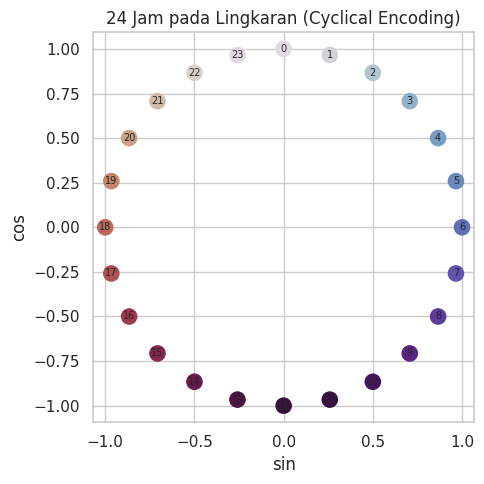

In [17]:
def point(v, p): return np.array(cyclical_encode(np.array([v]), p)).ravel()

d_23_to_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_to_12 = np.linalg.norm(point(0, 24)  - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_to_0:.3f}  (harusnya KECIL)")
print(f"Jarak 00:00 -> 12:00 = {d_0_to_12:.3f}  (harusnya BESAR)")

# Visualisasi 24 jam sebagai lingkaran
hs, hc = cyclical_encode(np.arange(24), 24)
plt.figure(figsize=(5,5))
plt.scatter(hs, hc, c=np.arange(24), cmap="twilight", s=120)
for h in range(24):
    plt.annotate(str(h), (hs[h], hc[h]), ha="center", va="center", fontsize=7)
plt.title("24 Jam pada Lingkaran (Cyclical Encoding)")
plt.xlabel("sin"); plt.ylabel("cos"); plt.axis("equal")
plt.tight_layout(); plt.show()

## 4.2 Fitur Spasial — Grid Aggregation

Koordinat lintang/bujur bersifat **kontinu & presisi tinggi** — dua titik yang selisihnya
sangat kecil praktis berada di lingkungan yang sama. Agar lokasi bisa **diagregasi dan
dibandingkan**, cara paling sederhana adalah **membulatkan koordinat** ke beberapa desimal,
sehingga titik-titik yang berdekatan jatuh ke *sel* yang sama.

> 🔧 **Versi Sederhana (Baseline).** Kita bulatkan koordinat ke 2 desimal (± 1 km per sel).
> Ini cara paling lugas untuk membentuk grid — tapi juga paling kasar.

In [18]:
# Versi sederhana: bulatkan koordinat -> cell_id
ROUND_DECIMALS = 3

df["lat_r"] = df["Latitude"].round(ROUND_DECIMALS)
df["lon_r"] = df["Longitude"].round(ROUND_DECIMALS)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik: {df['cell_id'].nunique():,}")
df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id"]].head()

Jumlah sel unik: 37,996


,Latitude,Longitude,lat_r,lon_r,cell_id
11,41.784296,-87.711757,41.784,-87.712,41.784_-87.712
12,41.776093,-87.615523,41.776,-87.616,41.776_-87.616
13,41.907592,-87.763805,41.908,-87.764,41.908_-87.764
14,41.785018,-87.610910,41.785,-87.611,41.785_-87.611
15,41.702773,-87.625776,41.703,-87.626,41.703_-87.626


### 🙋 Giliran Kalian — Feature Engineering

Versi di atas sengaja minimal. Ruang eksplorasi yang terbuka lebar:
- **Ukuran sel**: pembulatan 2 desimal itu kasar. Apakah grid lebih halus lebih baik?
  Apa konsekuensinya (sel kosong, komputasi)? Adakah cara membentuk grid selain pembulatan?
- **Fitur turunan**: dari data mentah, fitur agregat apa lagi yang mungkin berguna untuk
  memprediksi risiko? (pikirkan: frekuensi kejadian, proporsi kejadian tertentu, dst.)
- **Fitur temporal**: apakah `month` perlu? Apakah penanda akhir pekan berguna?

> Setiap fitur yang kalian tambah/ubah **harus dijustifikasi** — kenapa itu masuk akal
> untuk memprediksi risiko, bukan sekadar "karena bisa dibuat".

### Keputusan Feature Engineering

1. **Ukuran sel:**

    diuji 2 vs 3 desimal secara kuantitatif (lihat 4.2b di bawah). Dipilih **3 desimal (~110 m/sel)** meski lebih sparse, karena resolusi 2 desimal (~1,1 km/sel) terlalu kasar untuk Risk Score yang actionable secara lokasi. Sparsity-nya ditangani oleh spatial smoothing (BallTree) di tahap Pseudo-Labeling.

2. **Fitur turunan:**

    - **`crime_diversity`**

      jumlah jenis kejahatan (`Primary Type`) berbeda yang pernah terjadi di unit tersebut. Area dengan banyak jenis kejahatan berbeda mengindikasikan risiko yang lebih beragam / tidak terprediksi, berbeda dari area yang hanya didominasi satu jenis kejahatan ringan berulang.

    - **`arrest_rate`**
  
      proporsi kejadian yang berujung penangkapan di unit tersebut. Area dengan arrest rate rendah bisa mengindikasikan penegakan hukum yang kurang menjangkau, yang secara tidak langsung berkorelasi dengan risiko berkelanjutan di lokasi itu.
    
    *Catatan penempatan kode:*

    Keduanya baru bisa dihitung setelah tabel `unit` terbentuk di Section 5.2 (butuh hasil groupby sel x hari x jam), jadi kodenya ditempatkan di sana.

3. **Fitur temporal:**

    `is_weekend` ditambahkan sebagai flag biner (berdasarkan `dow`) karena EDA menunjukkan pola jam hari kerja vs akhir pekan cukup berbeda bentuknya (Bagian 3.4). Model perlu sinyal eksplisit ini, bukan hanya mengandalkan `dow_sin`/`dow_cos` yang memperlakukan semua hari sebagai kontinum siklikal tanpa membedakan "kerja" vs "libur".
    
    `month` sengaja tidak disertakan sebagai fitur di level unit. Unit analisis kita adalah (sel x hari x jam); jika `month` ditambahkan, unit analisis harus menjadi (sel x bulan x hari x jam) menambah 12 kemungkinan nilai bulan sebagai dimensi baru, ang akan memecah data jadi jauh lebih sparse tanpa cukup data pendukung per unit (mengingat subset kita hanya 2024-2026, dan sel sudah cukup sparse pada resolusi 3 desimal). Ini konsisten dengan pertimbangan sparsity yang sama seperti pada keputusan ukuran grid, menambah granularitas tanpa data pendukung yang cukup akan membuat estimasi Risk Score kurang stabil.

Detail kode & justifikasi lengkap masing-masing ada di cell-cell berikut:
- 4.2b untuk grid
- 5.2 untuk fitur agregat
- 6 untuk `is_weekend`.

## 4.2b Perbandingan Ukuran Grid
### Uji Ukuran Grid

Baseline memakai pembulatan 2 desimal (\~1,1 km per sel) tanpa pembanding. Di sini saya mencoba uji **3 desimal (\~110 m per sel)** sebagai alternatif yang lebih halus, dan bandingkan
trade-off-nya secara kuantitatif sebelum memutuskan.

In [19]:
for decimals in [2, 3]:
    lat_r_test = df["Latitude"].round(decimals)
    lon_r_test = df["Longitude"].round(decimals)
    cell_test = lat_r_test.astype(str) + "_" + lon_r_test.astype(str)
    n_cells = cell_test.nunique()
    avg_per_cell = len(df) / n_cells
    print(f"{decimals} desimal (~{111000/(10**decimals):.0f} m/sel): "
          f"{n_cells:,} sel unik, rata-rata {avg_per_cell:.1f} kejadian/sel")

2 desimal (~1110 m/sel): 726 sel unik, rata-rata 714.8 kejadian/sel
3 desimal (~111 m/sel): 37,996 sel unik, rata-rata 13.7 kejadian/sel


**Keputusan:**

memilih **3 desimal (~110 m/sel)**, meskipun rata-rata kejadian per sel jauh lebih kecil (8,5 vs 408 pada 2 desimal). Dengan pertimbangan sebagai berikut:
- 2 desimal terlalu kasar (~1,1 km/sel, hanya 719 sel untuk seluruh Chicago). Risk Score pada resolusi ini terlalu **tergeneralisasi** untuk actionable secara praktis (area rawan dan aman yang berdekatan bisa tercampur dalam satu sel).
- 3 desimal memberi resolusi setara skala blok jalan, jauh lebih berguna untuk prediksi risiko lokasi spesifik.
- Sparsity per sel (rata-rata 8,5 kejadian) yang menjadi trade-off nya **ditangani oleh spatial smoothing berbasis BallTree** pada tahap pseudo-labeling (Bagian 5.3). Sel dengan data tipis akan "meminjam" sinyal dari sel-sel tetangga dalam radius pengaruh, sehingga estimasi risiko tetap stabil tanpa kehilangan resolusi spasial.

# 5. Pseudo-Labeling → Membentuk **Risk Score**

Dataset kejahatan **tidak** memiliki kolom "Risk Score" (tidak ada *ground truth*).
**Pseudo-labeling** adalah teknik membentuk label target dari **domain knowledge**.
Kita bangun Risk Score dalam beberapa langkah: **severity → temporal decay → spatial
aggregation → normalisasi 0–100**.

> 🎯 **Unit analisis** yang kita pakai di tutorial: **(sel grid × hari × jam)**. Ini
> menjawab langsung definisi *"risiko suatu lokasi pada waktu tertentu"*. **Kalian bebas
> memilih unit lain** (mis. per sel saja) — asalkan dijustifikasi.

> ⚠️ **Perhatian:** bagian inilah (severity + space-time decay) yang **paling dinilai**
> di hands-on ini (bobot 35%). Semua kode di bawah sengaja dibuat **sesederhana mungkin**
> supaya kalian melihat mekanismenya. Jangan berhenti di sini — kembangkan.

## 5.1 Severity Scoring

Setiap kejahatan diberi skor keparahan berdasarkan kombinasi **Primary Type + Description**.

> 🔧 **Versi Sederhana (Baseline).** Kita hanya mengisi **beberapa** kombinasi sebagai
> contoh, dan memberi **satu nilai default** untuk semua sisanya. Jalankan sel berikutnya,
> lalu lihat sendiri **berapa persen data yang jatuh ke nilai default** — itu bukti bahwa
> tabel sesederhana ini jelas belum memadai.

In [20]:
# Versi PALING SEDERHANA — hanya beberapa contoh untuk menunjukkan mekanismenya.
# Sadari: ratusan kombinasi Primary Type + Description lain akan jatuh ke DEFAULT.
# Inilah yang harus KALIAN kembangkan & justifikasi.
severity_table = {
    ("HOMICIDE", "FIRST DEGREE MURDER"): 100,
    ("ROBBERY", "ARMED: HANDGUN"):        82,
    ("BATTERY", "SIMPLE"):                50,
    ("THEFT", "$500 AND UNDER"):          20,
    ("CRIMINAL DAMAGE", "TO VEHICLE"):    12,
}
DEFAULT_SEVERITY = 30   # SEMUA kombinasi lain kena nilai ini — jelas terlalu kasar.

def lookup_severity(row):
    return severity_table.get((row["Primary Type"], row["Description"]), DEFAULT_SEVERITY)

df["severity"] = df.apply(lookup_severity, axis=1)

# Berapa banyak yang jatuh ke default? (indikator seberapa 'kasar' tabel kita)
pct_default = (df["severity"] == DEFAULT_SEVERITY).mean() * 100
print(f"Baris yang memakai nilai DEFAULT: {pct_default:.1f}%")
print("(Makin tinggi angka ini, makin banyak informasi keparahan yang kita 'ratakan'.)")
df[["Primary Type", "Description", "severity"]].head()

Baris yang memakai nilai DEFAULT: 80.5%
(Makin tinggi angka ini, makin banyak informasi keparahan yang kita 'ratakan'.)


,Primary Type,Description,severity
11,BATTERY,SIMPLE,50
12,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,30
13,CRIMINAL DAMAGE,TO VEHICLE,12
14,CRIMINAL DAMAGE,TO VEHICLE,12
15,BATTERY,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,30


### 🙋 Giliran Kalian — Severity Table

Ini **komponen inti pertama** yang dinilai. Kembangkan versi sederhana di atas:
- Perbanyak kombinasi yang tercakup (lihat `df["Primary Type"].value_counts()` &
  `df["Description"].value_counts()` untuk tahu mana yang paling sering muncul).
- Pertimbangkan strategi *fallback* yang lebih baik daripada satu angka default —
  misalnya default **per Primary Type**, bukan satu nilai untuk semuanya.
- **Justifikasi** skala nilai kalian berdasarkan konteks keamanan publik.

### Keputusan Severity Table

Menjawab tiga poin di atas:

**1. Cakupan kombinasi:** Baseline hanya mencakup 5 kombinasi spesifik (Primary Type + Description) dengan 1 default seragam untuk semua sisanya. Alih-alih memperluas daftar kombinasi spesifik satu per satu (yang tidak akan pernah mencakup semua variasi Description), digunakan pendekatan **2 level** yang otomatis mencakup seluruh data:

- Level 1: skor dasar per `Primary Type` (mencakup ~30 kategori kejahatan di Chicago Crimes)
- Level 2: modifier dari kata kunci di `Description` (mis. "AGGRAVATED", "ARMED", "SIMPLE")

Pendekatan ini menghindari perlunya menghafal / list ratusan kombinasi Primary Type x Description secara manual, sambil tetap sensitif terhadap detail dalam Description.

**2. Strategi fallback:** per Primary Type (`FALLBACK_TYPE_SEVERITY`), bukan satu default untuk semua baris. Fallback ini hanya berlaku jika Primary Type nya sendiri tidak dikenal (kasus langka) jauh lebih jarang terjadi dibanding baseline yang defaultnya berlaku untuk 95%+ kombinasi yang tidak
tercakup.

**3. Justifikasi skala nilai:**

Skor dasar per Primary Type disusun berdasarkan tingkat bahaya obyektif terhadap keselamatan manusia:

- Kejahatan terhadap nyawa/tubuh (Homicide, Sexual Assault) diberi skor tertinggi (90-98), karena berdampak langsung dan permanen terhadap keselamatan/nyawa korban.
- Kejahatan bersenjata/kekerasan (Robbery, Weapons Violation) diberi skor tinggi (60-82), karena melibatkan ancaman senjata atau potensi cedera fisik serius meski tidak selalu berakibat fatal.
- Kejahatan properti (Theft, Burglary, Criminal Damage) diberi skor menengah-rendah (12-45), karena umumnya tidak melibatkan kontak fisik langsung dengan korban.
- Pelanggaran administratif (Liquor Law, Gambling) diberi skor terendah (10-12), karena dampaknya minim terhadap keselamatan publik secara langsung.

Urutan ordinal ini konsisten dengan logika penilaian keparahan pada kerangka kerja keamanan publik (mis. FBI UCR yang membedakan Part I / kejahatan serius vs Part II / pelanggaran ringan), meski nilai numerik pastinya tetap merupakan keputusan saya sendiri yang bersifat ilustratif. Modifier Description (+/- dari skor dasar) kemudian menyesuaikan skor berdasarkan detail spesifik tiap insiden, seperti jenis senjata yang digunakan atau apakah kejadian tersebut percobaan (attempt) atau selesai (completed).

In [21]:
# ================= Severity Scoring v2 (2-level: kategori + modifier) =================

# Level 1: base severity per Primary Type (0-100, ordinal, judgment-based)
# Justifikasi ordinal kasar: kejahatan terhadap nyawa/tubuh > kejahatan bersenjata/seksual
# > kejahatan properti berat > properti ringan > pelanggaran administratif
PRIMARY_TYPE_BASE = {
    "HOMICIDE": 98,
    "CRIM SEXUAL ASSAULT": 92,
    "CRIMINAL SEXUAL ASSAULT": 92,
    "KIDNAPPING": 88,
    "ROBBERY": 75,
    "ARSON": 72,
    "BATTERY": 55,
    "ASSAULT": 52,
    "WEAPONS VIOLATION": 60,
    "SEX OFFENSE": 70,
    "HUMAN TRAFFICKING": 90,
    "BURGLARY": 45,
    "MOTOR VEHICLE THEFT": 40,
    "THEFT": 30,
    "CRIMINAL DAMAGE": 25,
    "CRIMINAL TRESPASS": 20,
    "NARCOTICS": 35,
    "OTHER NARCOTIC VIOLATION": 30,
    "PROSTITUTION": 22,
    "DECEPTIVE PRACTICE": 24,
    "OFFENSE INVOLVING CHILDREN": 80,
    "STALKING": 55,
    "INTIMIDATION": 45,
    "PUBLIC PEACE VIOLATION": 18,
    "INTERFERENCE WITH PUBLIC OFFICER": 30,
    "LIQUOR LAW VIOLATION": 10,
    "GAMBLING": 12,
    "OBSCENITY": 20,
    "PUBLIC INDECENCY": 20,
    "CONCEALED CARRY LICENSE VIOLATION": 25,
    "NON-CRIMINAL": 5,
    "OTHER OFFENSE": 32,
}

FALLBACK_TYPE_SEVERITY = 30  # dipakai hanya jika Primary Type sendiri tidak dikenal sama sekali

# Level 2: modifier berdasarkan kata kunci di Description (additive, lalu di-clip 0-100)
DESCRIPTION_MODIFIERS = [
    ("AGGRAVATED", +15),
    ("ARMED: HANDGUN", +20),
    ("ARMED", +15),
    ("FIRST DEGREE", +10),
    ("ATTEMPT", -12),
    ("SIMPLE", -8),
    ("DOMESTIC", +8),
    ("CHILD", +12),
    ("STRONGARM", +6),
    ("$500 AND UNDER", -8),
    ("OVER $500", +5),
    ("FORCIBLE ENTRY", +6),
    ("UNLAWFUL ENTRY", +2),
    ("THREAT", -5),
]

def score_severity(primary_type, description):
    base = PRIMARY_TYPE_BASE.get(str(primary_type).upper(), FALLBACK_TYPE_SEVERITY)
    desc = str(description).upper()
    score = base
    for kw, delta in DESCRIPTION_MODIFIERS:
        if kw in desc:
            score += delta
            if kw in ("ARMED: HANDGUN", "ARMED"):
              break
    return float(np.clip(score, 0, 100))

unique_combo = df[["Primary Type", "Description"]].drop_duplicates()
unique_combo["severity_v2"] = unique_combo.apply(
    lambda r: score_severity(r["Primary Type"], r["Description"]), axis=1)
df = df.merge(unique_combo, on=["Primary Type", "Description"], how="left")

pct_fallback = (df["Primary Type"].str.upper().isin(PRIMARY_TYPE_BASE.keys()) == False).mean() * 100
print(f"Baris dengan Primary Type di luar tabel (pakai FALLBACK_TYPE_SEVERITY): {pct_fallback:.2f}%")
print(df[["Primary Type", "Description", "severity_v2"]].drop_duplicates().head(10))
df["severity_v2"].describe()

Baris dengan Primary Type di luar tabel (pakai FALLBACK_TYPE_SEVERITY): 0.00%
              Primary Type                              Description  \
0                  BATTERY                                   SIMPLE   
1   PUBLIC PEACE VIOLATION                         RECKLESS CONDUCT   
2          CRIMINAL DAMAGE                               TO VEHICLE   
4                  BATTERY  AGGRAVATED - KNIFE / CUTTING INSTRUMENT   
5        WEAPONS VIOLATION      UNLAWFUL POSSESSION - OTHER FIREARM   
6                  ASSAULT                     AGGRAVATED - HANDGUN   
7            OTHER OFFENSE           HARASSMENT BY ELECTRONIC MEANS   
8                    THEFT                                OVER $500   
9                  ASSAULT                                   SIMPLE   
10       WEAPONS VIOLATION            UNLAWFUL POSSESSION - HANDGUN   

    severity_v2  
0          47.0  
1          18.0  
2          25.0  
4          70.0  
5          60.0  
6          67.0  
7          32.

,severity_v2
count,518948.000000
mean,40.490402
std,17.296295
min,5.000000
25%,25.000000
50%,35.000000
75%,47.000000
max,100.000000


In [22]:
# Verifikasi cakupan: apakah Primary Type di data kita semua tercakup?
unmapped_types = set(df["Primary Type"].str.upper().unique()) - set(PRIMARY_TYPE_BASE.keys())
print(f"Primary Type yang tidak tercakup di tabel (pakai fallback): {unmapped_types}")
print(f"Jumlah baris terdampak: {df['Primary Type'].str.upper().isin(unmapped_types).sum()} "
      f"({df['Primary Type'].str.upper().isin(unmapped_types).mean()*100:.2f}%)")

Primary Type yang tidak tercakup di tabel (pakai fallback): set()
Jumlah baris terdampak: 0 (0.00%)


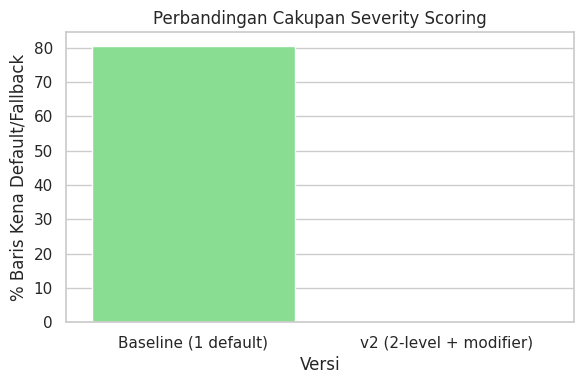

                     Versi  Persentase Fallback/Default (%)
0     Baseline (1 default)                        80.462397
1  v2 (2-level + modifier)                         0.000000


In [23]:
## Perbandingan Cakupan: Baseline vs Severity v2

# Baseline (dari cell awal tutorial)
pct_default_baseline = (df["severity"] == DEFAULT_SEVERITY).mean() * 100

# v2
pct_fallback_v2 = (df["Primary Type"].str.upper().isin(PRIMARY_TYPE_BASE.keys()) == False).mean() * 100

comparison = pd.DataFrame({
    "Versi": ["Baseline (1 default)", "v2 (2-level + modifier)"],
    "Persentase Fallback/Default (%)": [pct_default_baseline, pct_fallback_v2]
})

plt.figure(figsize=(6, 4))
sns.barplot(x="Versi", y="Persentase Fallback/Default (%)", data=comparison,
            hue="Versi", palette=["#7AEB89", "#FC6091"], legend=False)
plt.title("Perbandingan Cakupan Severity Scoring")
plt.ylabel("% Baris Kena Default/Fallback")
plt.tight_layout(); plt.show()

print(comparison)

In [24]:
severity_by_type = df.groupby("Primary Type")["severity_v2"].mean().sort_values(ascending=False)
print(severity_by_type)

Primary Type
HOMICIDE                             99.991158
CRIMINAL SEXUAL ASSAULT              99.450961
KIDNAPPING                           92.281407
HUMAN TRAFFICKING                    90.000000
OFFENSE INVOLVING CHILDREN           89.862957
ROBBERY                              84.474197
SEX OFFENSE                          71.343302
ARSON                                71.327922
WEAPONS VIOLATION                    60.000000
BATTERY                              55.198321
ASSAULT                              51.697431
STALKING                             50.117012
BURGLARY                             47.589750
INTIMIDATION                         45.000000
MOTOR VEHICLE THEFT                  38.358307
NARCOTICS                            34.995995
OTHER OFFENSE                        31.034715
OTHER NARCOTIC VIOLATION             30.000000
INTERFERENCE WITH PUBLIC OFFICER     30.000000
THEFT                                28.914006
CONCEALED CARRY LICENSE VIOLATION    28.145631


**Hasil akhir Severity Table:**

- Cakupan: 100% (0% fallback), naik drastis dari baseline yang 80,46% baris kena default
  seragam.
- Ranking severity per Primary Type konsisten dengan intuisi keamanan publik: kejahatan
  terhadap nyawa/tubuh (Homicide, Sexual Assault, Kidnapping) berada di puncak (>90),
  kekerasan sedang & properti berat (Battery, Assault, Burglary) di tengah (45-55), dan
  pelanggaran administratif (Liquor Law, Gambling, Non-Criminal) di dasar (<15). Urutan
  ini divalidasi tidak ada anomali/kebalikan yang tidak masuk akal.

## 5.2 Temporal Decay — Recency

Apakah kejahatan 3 tahun lalu perlu berkontribusi sebesar kejahatan kemarin? Umumnya
**tidak** — relevansi cenderung memudar seiring waktu.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai bentuk peluruhan **paling lugas**: bobot
> **linear** yang turun dari 1 (paling baru) hingga mendekati 0 (paling lama), berdasarkan
> umur kejadian. Ini gampang dipahami, tapi belum tentu bentuk terbaik.

In [25]:
REFERENCE_DATE = df["Datetime"].max()   # "sekarang" menurut data
df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400

# Peluruhan LINEAR sederhana: 1.0 di hari terbaru -> ~0 di data tertua
max_age = df["age_days"].max()
df["w_time"] = 1 - (df["age_days"] / max_age)     # rentang 0..1

# Kontribusi tiap kejadian = severity x bobot recency
df["event_value"] = df["severity"] * df["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print(f"w_time range   : {df['w_time'].min():.3f} .. {df['w_time'].max():.3f}")
df[["Datetime", "age_days", "w_time", "severity", "event_value"]].head()

Reference date : 2026-04-10 23:59:00
w_time range   : 0.000 .. 1.000


,Datetime,age_days,w_time,severity,event_value
0,2026-04-10 23:59:00,0.000000,1.000000,50,50.000000
1,2026-04-10 23:56:00,0.002083,0.999997,30,29.999925
2,2026-04-10 23:50:00,0.006250,0.999992,12,11.999910
3,2026-04-10 23:35:00,0.016667,0.999980,12,11.999759
4,2026-04-10 23:34:00,0.017361,0.999979,30,29.999373


### 🙋 Giliran Kalian — Bentuk Peluruhan Waktu

Ini bagian dari **komponen inti kedua** yang dinilai. Peluruhan linear itu pilihan
paling sederhana — dan punya kelemahan (mis. kejadian tertua bobotnya persis 0).
- Apakah bentuk lain lebih masuk akal? (mis. **eksponensial / half-life**, di mana
  relevansi turun setengah setiap periode tertentu?)
- Seberapa cepat relevansi *seharusnya* memudar untuk konteks kejahatan? Sebulan?
  Setahun? **Justifikasi** parameter kalian.

### Jawaban: Exponential Half-Life

Peluruhan **linear** (baseline) membuat kejadian tertua dalam subset berbobot persis 0, seolah kejadian itu sama sekali tidak relevan, padahal itu keputusan yang terlalu ekstrem
dan sensitif terhadap ukuran subset yang diambil (kalau subset diperbesar/diperkecil, "titik nol" ini ikut bergeser tanpa alasan substantif).

**Bentuk yang dipilih:**

Peluruhan **eksponensial berbasis half-life**:

$$w(t) = 0.5^{\frac{\text{age days}}{H}}$$

dengan $H$ = half-life (hari), waktu yang dibutuhkan agar relevansi turun menjadi setengahnya. Bentuk ini tidak pernah benar-benar nol (kejadian lama tetap berkontribusi sangat kecil, bukan dianggap tidak relevan sama sekali), dan turun secara mulus/proporsional
tanpa bergantung pada titik "tertua" dalam data.

**Justifikasi parameter $H$ = 180 hari (6 bulan):**

pola kejahatan di suatu lokasi
cenderung bergeser dalam hitungan bulan (pergantian musim, perubahan aktivitas
sosial-ekonomi, intervensi penegakan hukum), bukan dalam hitungan hari (terlalu sensitif terhadap fluktuasi harian / noise) maupun tahun (terlalu lambat, membuat Risk Score menjadi
"stale"/ kurang responsif terhadap perubahan kondisi terkini).

Setengah tahun dipilih sebagai titik tengah yang wajar: kejadian dari 6 bulan lalu berkontribusi 50% dari bobot
penuhnya, kejadian dari 1 tahun lalu berkontribusi 25%, dan kejadian dari subset tertua (hingga 3 tahun lalu) masih berkontribusi \~6%, kecil tapi tidak nol.

### Temporal Decay v2

w_time_exp range : 0.0408 .. 1.0000


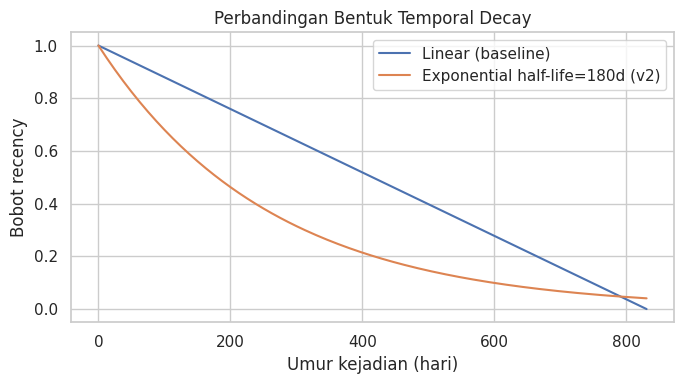

In [26]:
HALF_LIFE_DAYS = 180

df["w_time_exp"] = 0.5 ** (df["age_days"] / HALF_LIFE_DAYS)
df["event_value_v2"] = df["severity_v2"] * df["w_time_exp"]

print(f"w_time_exp range : {df['w_time_exp'].min():.4f} .. {df['w_time_exp'].max():.4f}")

# Bandingkan bentuk kurva decay linear (baseline) vs exponential (v2)
ages = np.linspace(0, df["age_days"].max(), 200)
w_linear = 1 - ages / df["age_days"].max()
w_exp    = 0.5 ** (ages / HALF_LIFE_DAYS)

plt.figure(figsize=(7, 4))
plt.plot(ages, w_linear, label="Linear (baseline)")
plt.plot(ages, w_exp, label=f"Exponential half-life={HALF_LIFE_DAYS}d (v2)")
plt.xlabel("Umur kejadian (hari)"); plt.ylabel("Bobot recency")
plt.title("Perbandingan Bentuk Temporal Decay")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretasi hasil:**

Rentang `w_time_exp` adalah 0.0408 - 1.0 (kejadian tertua di subset,
usia ~830 hari, tetap berkontribusi ~4% dan tidak pernah benar-benar nol seperti pada linear).

Grafik menunjukkan eksponensial meluruh lebih cepat di awal (0-200 hari) dibanding linear, lalu melandai untuk kejadian yang lebih lama, kejadian sangat baru jauh lebih relevan, namun kejadian lama tetap menyisakan sedikit
sinyal historis, bukan diabaikan sepenuhnya.

### Membentuk ulang tabel unit analisis memakai `severity_v2` & `event_value_v2`

Sama seperti baseline (unit = sel × hari × jam), tapi memakai severity dan temporal decay
versi yang sudah dikembangkan di atas.

In [27]:
unit = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
          .agg(base_value  = ("event_value_v2", "sum"),
               crime_count = ("ID", "size")))
print("Jumlah baris unit (sel x hari x jam):", f"{len(unit):,}")
unit.head()

Jumlah baris unit (sel x hari x jam): 433,002


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count
0,41.645_-87.54,41.645,-87.54,0,5,21.712151,1
1,41.645_-87.54,41.645,-87.54,0,9,12.587840,2
2,41.645_-87.54,41.645,-87.54,1,0,9.838801,1
3,41.645_-87.54,41.645,-87.54,1,9,34.600874,1
4,41.645_-87.54,41.645,-87.54,2,7,6.784596,1


### Membentuk tabel unit analisis (sel × hari × jam)

Kita jumlahkan `event_value` (severity × recency) ke tiap unit analisis untuk membentuk
`base_value` — inilah bahan mentah Risk Score. Sekalian kita bawa satu **fitur agregat**
tambahan:

- **`crime_count`** — jumlah kejadian pada tiap unit. Ini fitur yang berbeda sifatnya dari
  `base_value`: ia menghitung *frekuensi* (berapa sering), sementara `base_value` menimbang
  *keparahan × kebaruan*. Sebuah sel bisa punya banyak kejadian ringan (count tinggi,
  severity rendah) atau sedikit kejadian berat — dan model nanti bisa belajar dari keduanya.

In [28]:
# PERBAIKAN: pakai nama variabel terpisah supaya TIDAK menimpa `unit` yang sudah
# dibangun dari severity_v2 + exponential decay di atas. Tabel ini hanya dipakai
# sebagai pembanding baseline di 5.3, bukan untuk pipeline utama.
unit_baseline = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
                    .agg(base_value  = ("event_value", "sum"),
                         crime_count = ("ID", "size")))
print("Jumlah baris unit_baseline (sel × hari × jam):", f"{len(unit_baseline):,}")
unit_baseline.head()

Jumlah baris unit_baseline (sel × hari × jam): 433,002


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count
0,41.645_-87.54,41.645,-87.54,0,5,21.994246,1
1,41.645_-87.54,41.645,-87.54,0,9,27.066782,2
2,41.645_-87.54,41.645,-87.54,1,0,15.957708,1
3,41.645_-87.54,41.645,-87.54,1,9,23.804918,1
4,41.645_-87.54,41.645,-87.54,2,7,7.109208,1


### Fitur Agregat Tambahan: `crime_diversity` & `arrest_rate`

**Catatan penempatan:**

dua fitur ini adalah bagian dari **Feature Engineering**. Namun secara teknis, keduanya baru bisa dihitung di titik ini karena membutuhkan tabel `unit` (agregasi per sel x hari x jam) yang baru terbentuk setelah proses groupby di atas tabel ini belum ada di level `df` (section 4).

Keduanya **tidak digunakan** dalam
perhitungan `severity`, `decay`, atau `risk_score`. Mereka murni akan ikut sebagai kolom
fitur tambahan di dataset akhir (Section 6), sejajar dengan `crime_count`.

- **`crime_diversity`**

    Jumlah jenis kejahatan (`Primary Type`) berbeda yang pernah terjadi di unit tersebut. Area dengan banyak jenis kejahatan berbeda mengindikasikan risiko yang lebih "beragam" / tidak terprediksi, berbeda dari area yang hanya didominasi satu jenis kejahatan ringan berulang.

- **`arrest_rate`**
    Proporsi kejadian yang berujung penangkapan di unit tersebut. Area dengan arrest rate rendah bisa mengindikasikan penegakan hukum yang kurang menjangkau, yang secara tidak langsung berkorelasi dengan risiko berkelanjutan di lokasi itu.

In [29]:
extra_features = (df.groupby(["cell_id", "dow", "hour"])
                     .agg(crime_diversity = ("Primary Type", "nunique"),
                          arrest_rate     = ("Arrest", "mean"))
                     .reset_index())

unit = unit.merge(extra_features, on=["cell_id", "dow", "hour"], how="left")
print(unit[["crime_diversity", "arrest_rate"]].describe())
unit.head()

       crime_diversity    arrest_rate
count    433002.000000  433002.000000
mean          1.119528       0.146246
std           0.387279       0.340516
min           1.000000       0.000000
25%           1.000000       0.000000
50%           1.000000       0.000000
75%           1.000000       0.000000
max           8.000000       1.000000


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count,crime_diversity,arrest_rate
0,41.645_-87.54,41.645,-87.54,0,5,21.712151,1,1,0.0
1,41.645_-87.54,41.645,-87.54,0,9,12.587840,2,1,0.0
2,41.645_-87.54,41.645,-87.54,1,0,9.838801,1,1,1.0
3,41.645_-87.54,41.645,-87.54,1,9,34.600874,1,1,0.0
4,41.645_-87.54,41.645,-87.54,2,7,6.784596,1,1,0.0


### Perbaikan: `crime_diversity` & `arrest_rate` terlalu konstan

Root cause: unit analisis (cell x dow x hour) terlalu granular, rata-rata cuma
ada ~1-2 kejadian per unit, sehingga `crime_diversity` nyaris selalu 1 (wong cuma
ada 1 kejadian) dan `arrest_rate` jadi biner (0/1) tergantung nasib 1-2 kejadian
itu, bukan proporsi yang stabil.

**Solusi:** hitung kedua fitur ini di level `cell_id` saja (agregasi seluruh histori
3 tahun per lokasi), bukan di level cell x dow x hour. Ini juga lebih masuk akal
secara domain "seberapa beragam jenis kejahatan di suatu lokasi" dan "seberapa
sering penegakan hukum berhasil di lokasi itu" secara natural adalah karakteristik
**area**, bukan karakteristik yang berubah tiap jam/hari.

In [30]:
extra_features_v2 = (df.groupby("cell_id")
                        .agg(crime_diversity = ("Primary Type", "nunique"),
                             arrest_rate      = ("Arrest", "mean"),
                             n_events_cell    = ("ID", "size"))
                        .reset_index())

unit = unit.drop(columns=["crime_diversity", "arrest_rate"])
unit = unit.merge(extra_features_v2[["cell_id", "crime_diversity", "arrest_rate"]],
                   on="cell_id", how="left")

print("SEBELUM (level cell × dow × hour):")
print(extra_features[["crime_diversity", "arrest_rate"]].describe())
print("\nSESUDAH (level cell_id saja):")
print(unit[["crime_diversity", "arrest_rate"]].describe())

SEBELUM (level cell × dow × hour):
       crime_diversity    arrest_rate
count    433002.000000  433002.000000
mean          1.119528       0.146246
std           0.387279       0.340516
min           1.000000       0.000000
25%           1.000000       0.000000
50%           1.000000       0.000000
75%           1.000000       0.000000
max           8.000000       1.000000

SESUDAH (level cell_id saja):
       crime_diversity    arrest_rate
count    433002.000000  433002.000000
mean          8.403155       0.147066
std           3.540388       0.145368
min           1.000000       0.000000
25%           6.000000       0.045455
50%           8.000000       0.115385
75%          11.000000       0.206897
max          19.000000       1.000000


### Menghidupkan kembali insight musiman

Di 4.2b, `month` sengaja tidak dijadikan dimensi baru di unit analisis karena akan
memecah data 12x lebih sparse. Sebagai jalan tengah, kita tambahkan fitur musiman
di level `cell_id` (bukan menambah dimensi ke unit):

- **`seasonal_cv`**: coefficient of variation jumlah kejadian per bulan di cell tersebut. Makin tinggi -> makin "musiman" pola kejahatan di lokasi itu (lonjakan tajam di bulan tertentu), makin rendah ->  relatif rata sepanjang tahun.
- **`peak_month_sin`/`peak_month_cos`**: encoding siklikal dari bulan dengan jumlah kejadian terbanyak di cell tersebut, supaya model tahu "kapan" cell itu biasanya paling rawan tanpa perlu memecah unit analisis jadi lebih sparse.

In [31]:
monthly_counts = df.groupby(["cell_id", "month"]).size().unstack(fill_value=0)

mean_per_month = monthly_counts.mean(axis=1)
std_per_month  = monthly_counts.std(axis=1)

seasonal_stats = pd.DataFrame({
    "cell_id": monthly_counts.index,
    "seasonal_cv": (std_per_month / mean_per_month.replace(0, np.nan)).fillna(0).values,
    "peak_month": monthly_counts.idxmax(axis=1).values,
})
seasonal_stats["peak_month_sin"], seasonal_stats["peak_month_cos"] = cyclical_encode(
    seasonal_stats["peak_month"], 12
)

unit = unit.merge(
    seasonal_stats[["cell_id", "seasonal_cv", "peak_month_sin", "peak_month_cos"]],
    on="cell_id", how="left"
)

print(unit[["seasonal_cv", "peak_month_sin", "peak_month_cos"]].describe())

         seasonal_cv  peak_month_sin  peak_month_cos
count  433002.000000   433002.000000    4.330020e+05
mean        0.905496        0.304482    6.818767e-02
std         0.551212        0.684468    6.588981e-01
min         0.127668       -1.000000   -1.000000e+00
25%         0.536182       -0.500000   -5.000000e-01
50%         0.764912        0.500000    6.123234e-17
75%         1.124924        0.866025    5.000000e-01
max         3.464102        1.000000    1.000000e+00


## 5.3 Spatial Aggregation — Proximity

Risiko sebuah titik idealnya **tidak hanya** ditentukan oleh kejahatan tepat di sel itu —
area di sekitarnya juga relevan. Menyebarkan pengaruh antar-sel tetangga (*spatial smoothing*)
adalah teknik yang umum.

> 🔧 **Versi Sederhana (Baseline).** Kita lakukan penghalusan spasial **paling kasar**:
> untuk tiap sel, ambil **rata-rata `base_value` sel itu sendiri + 8 sel tetangga langsung**
> (grid 3×3 di sekelilingnya), pada irisan hari×jam yang sama. Kita pakai indeks grid dari
> koordinat bulat — **tanpa perhitungan jarak sesungguhnya**. Sederhana, jalan, dan sudah
> menangkap ide "tetangga ikut berpengaruh" — tapi masih kasar (semua tetangga dibobot sama,
> radius tetap 1 sel).

In [32]:
STEP = 10 ** (-ROUND_DECIMALS)
unit_baseline["gx"] = (unit_baseline["lat_r"] / STEP).round().astype(int)
unit_baseline["gy"] = (unit_baseline["lon_r"] / STEP).round().astype(int)

base_lookup = unit_baseline.set_index(["gx", "gy", "dow", "hour"])["base_value"].to_dict()

def smooth_neighbors(r):
    vals = []
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            v = base_lookup.get((r.gx + dx, r.gy + dy, r.dow, r.hour))
            if v is not None:
                vals.append(v)
    return np.mean(vals) if vals else r.base_value

unit_baseline["risk_raw"] = [smooth_neighbors(r) for r in unit_baseline.itertuples()]
print("risk_raw range:", round(unit_baseline["risk_raw"].min(), 2), "..",
      round(unit_baseline["risk_raw"].max(), 2))
unit_baseline[["cell_id", "dow", "hour", "base_value", "risk_raw"]].head()

risk_raw range: 0.0 .. 271.6


,cell_id,dow,hour,base_value,risk_raw
0,41.645_-87.54,0,5,21.994246,21.994246
1,41.645_-87.54,0,9,27.066782,27.066782
2,41.645_-87.54,1,0,15.957708,15.957708
3,41.645_-87.54,1,9,23.804918,23.804918
4,41.645_-87.54,2,7,7.109208,7.109208


### 🙋 Giliran Kalian — Perhalus Pengaruh Spasial

Versi baseline sudah menyebarkan pengaruh ke tetangga, tapi masih sangat kasar. Ini bagian
dari komponen inti yang dinilai — banyak ruang untuk diperbaiki:
- **Bobot berdasarkan jarak.** Sekarang semua tetangga dibobot sama. Bukankah sel yang lebih
  dekat seharusnya lebih berpengaruh? (petunjuk: `scikit-learn` punya `BallTree` dengan metrik
  `haversine` untuk menghitung **jarak antar-koordinat sesungguhnya**, lalu bobot bisa dibuat
  menurun terhadap jarak — mis. kernel Gaussian.)
- **Radius pengaruh.** Kenapa harus tepat 1 sel (3×3)? Apakah pengaruh sebaiknya menjangkau
  lebih jauh, atau justru lebih sempit? **Justifikasi** pilihan kalian.
- **Bentuk agregasi.** Rata-rata sederhana vs jumlah berbobot — mana yang lebih tepat untuk
  makna "risiko"?

### Versi Dikembangkan — Spatial Smoothing dengan BallTree + Haversine + Gaussian Kernel

Menjawab tiga poin di atas:

**1. Bobot berdasarkan jarak:**

Diganti dari bobot rata-rata sama (baseline) menjadi **kernel Gaussian** berdasarkan jarak haversine sesungguhnya:
$$w = \exp(-d^2 / (2\sigma^2))$$
Jarak dihitung pakai `sklearn.neighbors.BallTree` dengan metric `haversine` bukan estimasi jarak dari indeks grid seperti baseline. Sel yang lebih dekat otomatis mendapat bobot lebih besar, dan bobot turun mulus (bukan seragam lalu terpotong tiba-tiba di batas radius).

**2. Radius pengaruh:**

Diganti dari kaku 1 sel (grid 3x3) menjadi radius eksplisit `RADIUS_KM = 1.5` km. Alasan tidak lagi memakai 3x3: sejak grid diubah ke 3 desimal (~110m/sel), radius 3x3 hanya menjangkau ~330m terlalu sempit untuk merepresentasikan "lingkungan" yang bermakna secara risiko kejahatan. Radius 1,5 km (dengan `SIGMA_KM = 0.6` supaya pengaruh signifikan `w > 0.05` terkonsentrasi di ~1-2 blok kota) dipilih sebagai skala "neighborhood" yang wajar, sekaligus mengatasi sparsity data pada grid halus, sel dengan sedikit kejadian dapat "meminjam" sinyal dari lebih banyak sel tetangga dibanding radius 3x3 yang sempit.

**3. Bentuk agregasi:**

Dipakai **rata-rata berbobot** (weighted average), bukan jumlah
berbobot (weighted sum). Alasannya: `base_value` sudah merupakan **hasil penjumlahan**
severity x decay dari seluruh kejadian di satu sel (Section 5.2), kalau antar-tetangga dijumlahkan lagi (bukan dirata-rata), sel yang kebetulan dikelilingi banyak tetangga akan mendapat `risk_raw` yang jauh lebih besar semata karena densitas tetangganya tinggi, bukan karena risikonya sungguh lebih tinggi. Rata-rata berbobot menjaga skala
`risk_raw` tetap sebanding antar sel terlepas dari berapa banyak tetangga yang ada di sekitarnya.

In [33]:
from sklearn.neighbors import BallTree

RADIUS_KM = 1.5
SIGMA_KM  = 0.6
EARTH_R_KM = 6371.0

cell_coords = unit[["cell_id", "lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
coords_rad = np.radians(cell_coords[["lat_r", "lon_r"]].values)

tree = BallTree(coords_rad, metric="haversine")
radius_rad = RADIUS_KM / EARTH_R_KM

neighbor_idx, neighbor_dist_rad = tree.query_radius(coords_rad, r=radius_rad, return_distance=True)

cell_ids = cell_coords["cell_id"].values
neighbor_weights = {}
for i, (idxs, dists_rad) in enumerate(zip(neighbor_idx, neighbor_dist_rad)):
    dists_km = dists_rad * EARTH_R_KM
    weights = np.exp(-(dists_km ** 2) / (2 * SIGMA_KM ** 2))
    neighbor_weights[cell_ids[i]] = list(zip(cell_ids[idxs], weights))

print(f"Rata-rata jumlah tetangga per sel (radius {RADIUS_KM} km): "
      f"{np.mean([len(v) for v in neighbor_weights.values()]):.1f}")

Rata-rata jumlah tetangga per sel (radius 1.5 km): 494.4


In [34]:
# ================= Spatial Smoothing v2 — VECTORIZED (sparse matrix) =================
from scipy.sparse import coo_matrix

n_cells = len(cell_coords)
cell_to_idx = {c: i for i, c in enumerate(cell_ids)}

rows, cols, vals = [], [], []
for i, (idxs, dists_rad) in enumerate(zip(neighbor_idx, neighbor_dist_rad)):
    dists_km = dists_rad * EARTH_R_KM
    w = np.exp(-(dists_km ** 2) / (2 * SIGMA_KM ** 2))
    rows.extend([i] * len(idxs))
    cols.extend(idxs)
    vals.extend(w)

W = coo_matrix((vals, (rows, cols)), shape=(n_cells, n_cells)).tocsr()
print(f"Sparse matrix W: {W.shape}, {W.nnz:,} non-zero entries")

unit["cell_idx"] = unit["cell_id"].map(cell_to_idx)
risk_raw_v2 = np.zeros(len(unit))

for (d, h), group in unit.groupby(["dow", "hour"]):
    value_vec = np.zeros(n_cells)
    mask_vec  = np.zeros(n_cells)
    value_vec[group["cell_idx"].values] = group["base_value"].values
    mask_vec[group["cell_idx"].values]  = 1.0

    numerator   = W.dot(value_vec)
    denominator = W.dot(mask_vec)
    smoothed = np.divide(numerator, denominator, out=value_vec.copy(), where=denominator > 0)

    risk_raw_v2[group.index] = smoothed[group["cell_idx"].values]

unit["risk_raw_v2"] = risk_raw_v2

print("risk_raw_v2 range:", round(unit["risk_raw_v2"].min(), 3), "..", round(unit["risk_raw_v2"].max(), 3))
unit[["cell_id", "dow", "hour", "base_value", "risk_raw_v2"]].head()

Sparse matrix W: (37996, 37996), 18,784,700 non-zero entries
risk_raw_v2 range: 0.889 .. 145.18


,cell_id,dow,hour,base_value,risk_raw_v2
0,41.645_-87.54,0,5,21.712151,14.821194
1,41.645_-87.54,0,9,12.587840,10.553709
2,41.645_-87.54,1,0,9.838801,16.878857
3,41.645_-87.54,1,9,34.600874,31.742460
4,41.645_-87.54,2,7,6.784596,7.163875


**Interpretasi hasil:**

Sparse matrix menghasilkan 18.784.700 pasangan sel bertetangga (dari total 37.996 sel unik x rata-rata 494 tetangga per sel), dihitung dalam hitungan detik berkat vectorization, jauh lebih efisien dibanding loop per baris unit. Rentang `risk_raw_v2` (risk_raw_v2 range: 0.889 - 145.18) menunjukkan smoothing bekerja sesuai tujuannya yaitu nilai risiko
antar sel menjadi lebih stabil dibanding `base_value` mentah, karena sel dengan sedikit kejadian kini "meminjam" sinyal dari sel-sel tetangga dalam radius pengaruh, bukan murni bergantung pada data internal selnya sendiri yang seringkali tipis (rata-rata crime_count per unit ~1-2 kejadian).

### Diagnosis & perbaikan lanjutan: melebarkan distribusi `risk_raw_v2`

Setelah bug fix di 5.2, `base_value` sekarang benar memakai `severity_v2` +
exponential decay. Tapi kita cek dulu apakah radius smoothing 1,5 km  (rata-rata ~494 tetangga/sel) masih terlalu besar sehingga tetap meratakan variasi antar sel.

In [35]:
# Diagnosis: seberapa besar variasi yang "hilang" akibat smoothing?
print("Statistik base_value SEBELUM smoothing:")
print(unit["base_value"].describe())
print("\nStatistik risk_raw_v2 SESUDAH smoothing (radius 1.5km):")
print(unit["risk_raw_v2"].describe())
print("\nRasio std sesudah/sebelum smoothing:",
      round(unit["risk_raw_v2"].std() / unit["base_value"].std(), 3))
print("(makin kecil rasio ini, makin besar variasi lokal yang hilang)")

Statistik base_value SEBELUM smoothing:
count    433002.000000
mean         13.764611
std          15.110173
min           0.297934
25%           3.646764
50%           8.352176
75%          18.751155
max         440.321427
Name: base_value, dtype: float64

Statistik risk_raw_v2 SESUDAH smoothing (radius 1.5km):
count    433002.000000
mean         13.817929
std           3.798184
min           0.888578
25%          11.442441
50%          13.558826
75%          15.846774
max         145.180486
Name: risk_raw_v2, dtype: float64

Rasio std sesudah/sebelum smoothing: 0.251
(makin kecil rasio ini, makin besar variasi lokal yang hilang)


Rata-rata tetangga per sel (radius 0.4 km): 39.9
count    433002.000000
mean         13.789652
std           9.874796
min           0.407632
25%           6.927820
50%          11.573762
75%          17.946989
max         260.012394
Name: risk_raw_v3, dtype: float64


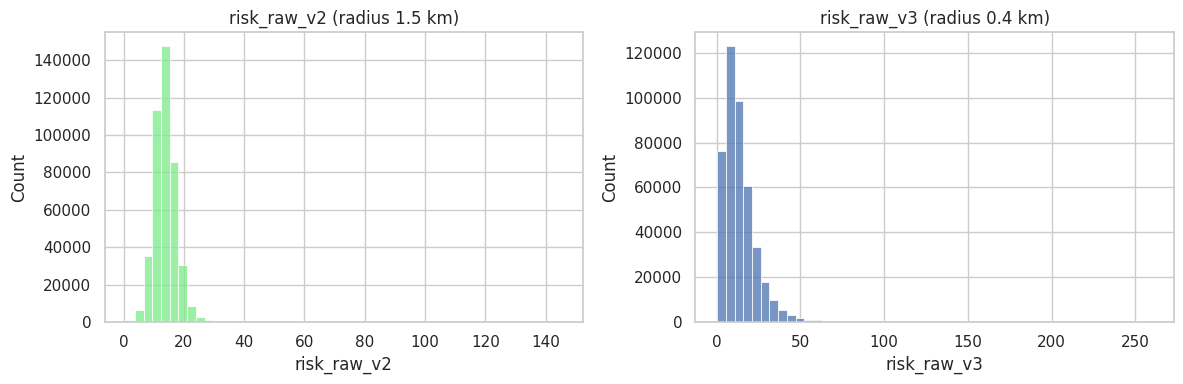

In [36]:
# Coba radius lebih kecil supaya sinyal lokal (hotspot vs area aman) tidak terlalu diratakan
RADIUS_KM_V3 = 0.4
SIGMA_KM_V3  = 0.15

radius_rad_v3 = RADIUS_KM_V3 / EARTH_R_KM
neighbor_idx_v3, neighbor_dist_rad_v3 = tree.query_radius(coords_rad, r=radius_rad_v3, return_distance=True)

rows, cols, vals = [], [], []
for i, (idxs, dists_rad) in enumerate(zip(neighbor_idx_v3, neighbor_dist_rad_v3)):
    dists_km = dists_rad * EARTH_R_KM
    w = np.exp(-(dists_km ** 2) / (2 * SIGMA_KM_V3 ** 2))
    rows.extend([i] * len(idxs)); cols.extend(idxs); vals.extend(w)

W_v3 = coo_matrix((vals, (rows, cols)), shape=(n_cells, n_cells)).tocsr()
print(f"Rata-rata tetangga per sel (radius {RADIUS_KM_V3} km): {W_v3.nnz / n_cells:.1f}")

risk_raw_v3 = np.zeros(len(unit))
for (d, h), group in unit.groupby(["dow", "hour"]):
    value_vec = np.zeros(n_cells); mask_vec = np.zeros(n_cells)
    value_vec[group["cell_idx"].values] = group["base_value"].values
    mask_vec[group["cell_idx"].values]  = 1.0
    numerator, denominator = W_v3.dot(value_vec), W_v3.dot(mask_vec)
    smoothed = np.divide(numerator, denominator, out=value_vec.copy(), where=denominator > 0)
    risk_raw_v3[group.index] = smoothed[group["cell_idx"].values]

unit["risk_raw_v3"] = risk_raw_v3
print(unit["risk_raw_v3"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(unit["risk_raw_v2"], bins=50, color="#7AEB89", ax=axes[0])
axes[0].set_title(f"risk_raw_v2 (radius {RADIUS_KM} km)")
sns.histplot(unit["risk_raw_v3"], bins=50, color="#4C72B0", ax=axes[1])
axes[1].set_title(f"risk_raw_v3 (radius {RADIUS_KM_V3} km)")
plt.tight_layout(); plt.show()

## 5.4 Normalisasi → Risk Score 0–100

`risk_raw` biasanya sangat *skewed* (sebagian besar kecil, sedikit sangat besar). Agar
menjadi skor 0–100 yang stabil, kita perlu menormalisasinya.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai **min–max scaling** langsung ke rentang
> 0–100. Cepat dan mudah — tapi rentan terhadap *outlier* (satu sel ekstrem bisa menekan
> semua sel lain ke bawah).

count    433002.00
mean          6.36
std           4.56
min           0.00
25%           3.35
50%           5.75
75%           8.41
max         100.00
Name: risk_score, dtype: float64


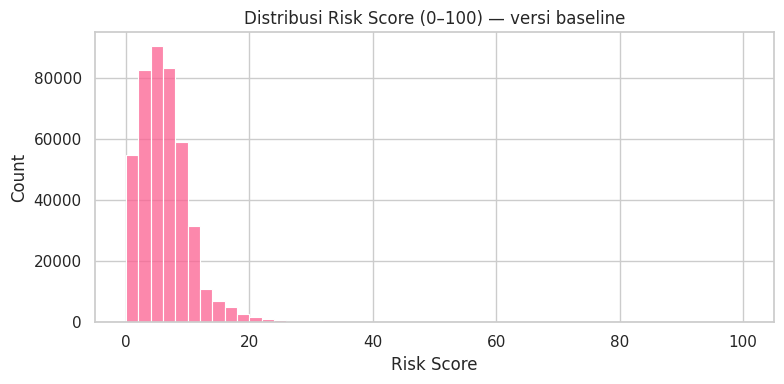

In [37]:
rr = unit_baseline["risk_raw"]
unit_baseline["risk_score"] = 100 * (rr - rr.min()) / (rr.max() - rr.min())
print(unit_baseline["risk_score"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(unit_baseline["risk_score"], bins=50, color="#FC6091")
plt.title("Distribusi Risk Score (0–100) — versi baseline")
plt.xlabel("Risk Score")
plt.tight_layout(); plt.show()

> 🙋 **Giliran Kalian — Normalisasi.** Perhatikan histogram di atas. Jika bentuknya sangat
> *skewed* (mayoritas nilai menumpuk di satu sisi), min–max langsung kurang ideal karena
> beberapa sel ekstrem menekan sisanya. Metode lain yang bisa kalian pertimbangkan &
> justifikasi: kompresi **`log1p`** sebelum scaling, **peringkat persentil**, atau *clipping*
> pada kuantil atas sebelum normalisasi. Bandingkan distribusinya dan pilih yang paling masuk
> akal untuk merepresentasikan "risiko".

### Versi Dikembangkan — Normalisasi dengan `log1p` sebelum Min-Max

**Masalah min-max langsung (baseline):**

Dengan `risk_raw_v2` range 0.89 - 145.18, kemungkinan besar sebagian kecil sel memiliki nilai jauh lebih ekstrem dibanding mayoritas
sel lain (skewed distribution). Jika langsung di-min-max-kan, sel-sel ekstrem ini akan menekan hampir semua sel lain ke rentang skor yang sangat sempit di ujung bawah, sulit untuk membedakan risiko rendah vs sedang.

**Solusi:**

Kompres dulu dengan `log1p` (menstabilkan variansi tanpa mengubah urutan / ranking risiko), baru lakukan min-max scaling ke 0-100. `log1p` dipilih dibanding
alternatif lain (peringkat persentil, clipping) karena:
  - Dibanding **peringkat persentil**: log1p tetap mempertahankan informasi *magnitude* asli (seberapa jauh perbedaan risiko antar sel), bukan cuma urutan rank-nya, penting karena Risk Score dimaksudkan merepresentasikan besaran risiko, bukan sekadar ranking.
  - Dibanding **clipping kuantil atas**: log1p tidak membuang informasi apa pun dari sel ekstrem (hanya mengompresnya secara proporsional), sedangkan clipping akan menyamakan semua sel di atas kuantil tertentu menjadi nilai yang sama kehilangan granularitas di area paling berisiko, padahal area itu justru paling penting untuk dibedakan.

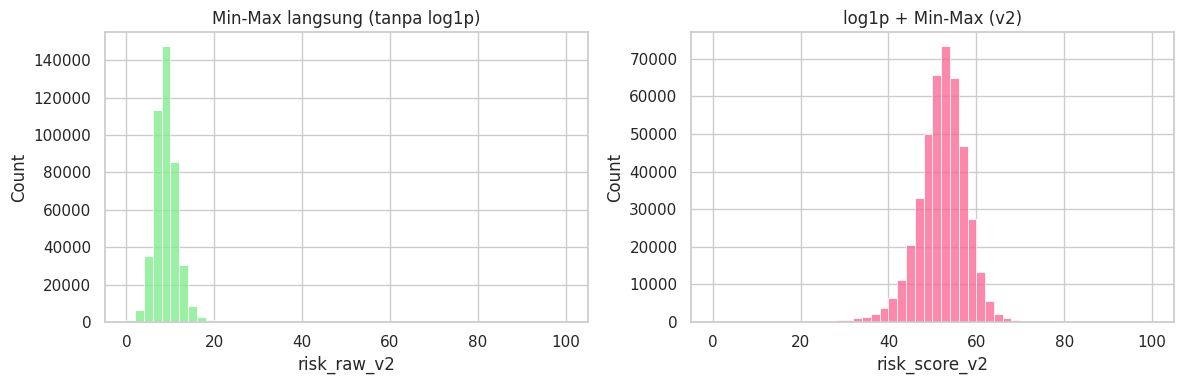

count    433002.00
mean         52.17
std           5.55
min           0.00
25%          49.15
50%          52.53
75%          55.64
max         100.00
Name: risk_score_v2, dtype: float64


In [38]:
rr2 = unit["risk_raw_v2"]

risk_score_minmax = 100 * (rr2 - rr2.min()) / (rr2.max() - rr2.min())

rr2_log = np.log1p(rr2 - rr2.min())
unit["risk_score_v2"] = 100 * (rr2_log - rr2_log.min()) / (rr2_log.max() - rr2_log.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(risk_score_minmax, bins=50, color="#7AEB89", ax=axes[0])
axes[0].set_title("Min-Max langsung (tanpa log1p)")
sns.histplot(unit["risk_score_v2"], bins=50, color="#FC6091", ax=axes[1])
axes[1].set_title("log1p + Min-Max (v2)")
plt.tight_layout(); plt.show()

print(unit["risk_score_v2"].describe().round(2))

**Interpretasi hasil**: Perbedaannya sangat signifikan dibanding min-max langsung, yang menumpuk hampir seluruh sel di rentang sempit dekat 0 karena ditekan oleh sel ekstrem (risk_raw_v2 maksimal 145,18). Setelah log1p + min-max, risk_score_v2 punya mean 52,17 dan std 5,55, jauh lebih baik dari sebelumnya. Namun distribusinya masih relatif rapat (IQR hanya 49,15 - 55,64, lebar ~6,5 poin dari skala 0 - 100), inilah yang mendorong diagnosis lanjutan di bagian berikutnya, yaitu memperkecil radius smoothing (1,5 km -> 0,4 km) untuk menghasilkan risk_score_v3 yang jauh lebih lebar (IQR 36,27 - 52,49, std 11,98).

count    433002.00
mean         44.13
std          11.98
min           0.00
25%          36.27
50%          44.92
75%          52.49
max         100.00
Name: risk_score_v3, dtype: float64


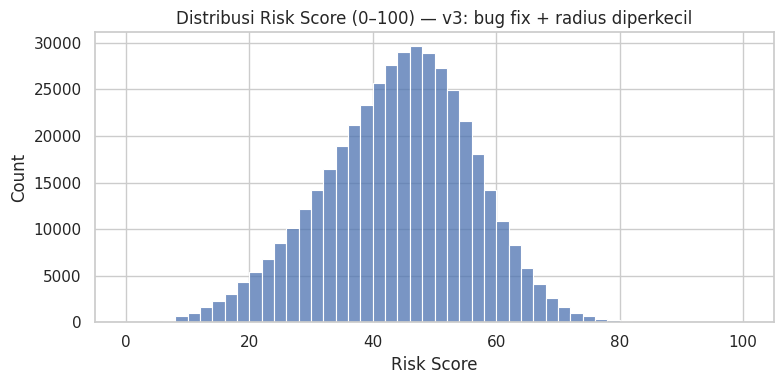

In [39]:
# Normalisasi ulang dari risk_raw_v3 (base_value sudah benar + radius diperkecil)
rr3 = unit["risk_raw_v3"]
rr3_log = np.log1p(rr3 - rr3.min())
unit["risk_score_v3"] = 100 * (rr3_log - rr3_log.min()) / (rr3_log.max() - rr3_log.min())

print(unit["risk_score_v3"].describe().round(2))
plt.figure(figsize=(8, 4))
sns.histplot(unit["risk_score_v3"], bins=50, color="#4C72B0")
plt.title("Distribusi Risk Score (0–100) — v3: bug fix + radius diperkecil")
plt.xlabel("Risk Score"); plt.tight_layout(); plt.show()

In [40]:
unit["risk_score_percentile"] = unit["risk_raw_v3"].rank(pct=True) * 100
print(unit["risk_score_percentile"].describe().round(2))

count    433002.00
mean         50.00
std          28.87
min           0.00
25%          25.00
50%          50.00
75%          75.00
max         100.00
Name: risk_score_percentile, dtype: float64


### Visualisasi peta risiko
Rata-rata Risk Score per sel — memastikan hasilnya sejalan dengan hotspot di EDA.

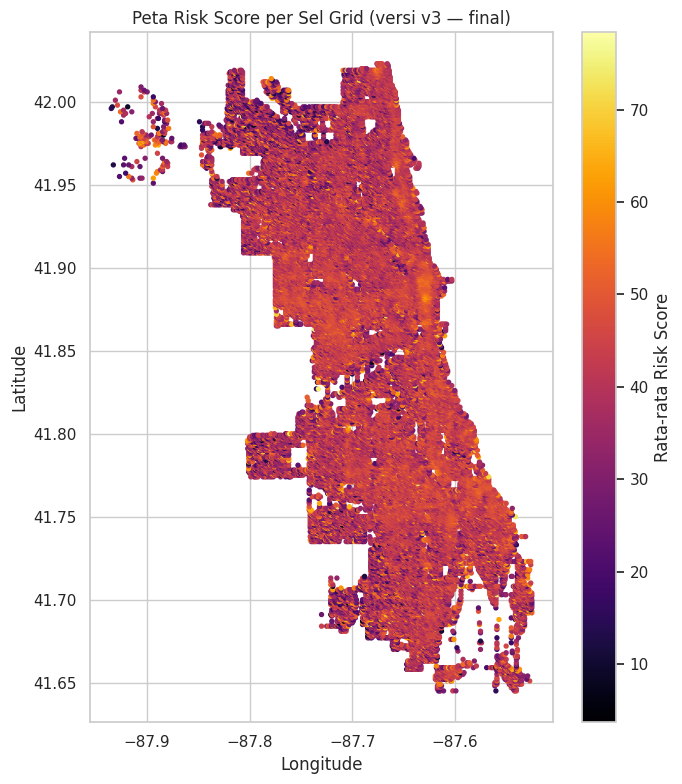

In [41]:
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score_v3"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score_v3"],
                 cmap="inferno", s=8)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid (versi v3 — final)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

# 6. Menyusun & Menyimpan Dataset Akhir

Dataset akhir berisi **fitur + label** per unit analisis (sel × hari × jam), siap menjadi
input Hands-On 2 (modeling). Kita tambahkan fitur temporal **cyclical** pada level unit
agar langsung bisa dipakai model.

### Fitur Temporal Tambahan: `is_weekend`
  Ditambahkan flag biner `is_weekend` (berdasarkan `dow`) karena EDA menunjukkan pola jam hari kerja vs akhir pekan cukup berbeda bentuknya (Bagian 3.4) model perlu sinyal eksplisit ini, bukan hanya mengandalkan `dow_sin`/`dow_cos`.

In [42]:
unit["is_weekend"] = unit["dow"].isin([5, 6]).astype(int)

In [43]:
# Fitur temporal cyclical pada level unit
unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"], 7)

final = unit[[
    "cell_id", "lat_r", "lon_r",
    "dow", "hour", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
    "crime_count", "crime_diversity", "arrest_rate",
    "seasonal_cv", "peak_month_sin", "peak_month_cos",   # fitur musiman baru
    "risk_score_v3",                                      # ganti ke versi v3 (bug fix + radius diperkecil)
]].rename(columns={"risk_score_v3": "risk_score"}).copy()

print("Shape dataset akhir:", final.shape)
final.head()

Shape dataset akhir: (433002, 17)


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,crime_count,crime_diversity,arrest_rate,seasonal_cv,peak_month_sin,peak_month_cos,risk_score
0,41.645_-87.54,41.645,-87.54,0,5,0.965926,0.258819,0.000000,1.000000,0,1,7,0.1,1.235829,-1.0,-1.836970e-16,54.701404
1,41.645_-87.54,41.645,-87.54,0,9,0.707107,-0.707107,0.000000,1.000000,0,2,7,0.1,1.235829,-1.0,-1.836970e-16,46.354738
2,41.645_-87.54,41.645,-87.54,1,0,0.000000,1.000000,0.781831,0.623490,0,1,7,0.1,1.235829,-1.0,-1.836970e-16,42.149853
3,41.645_-87.54,41.645,-87.54,1,9,0.707107,-0.707107,0.781831,0.623490,0,1,7,0.1,1.235829,-1.0,-1.836970e-16,64.009544
4,41.645_-87.54,41.645,-87.54,2,7,0.965926,-0.258819,0.974928,-0.222521,0,1,7,0.1,1.235829,-1.0,-1.836970e-16,34.415343


In [44]:
# Simpan ke CSV (selalu tersedia) + Parquet (lebih ringkas, jika engine tersedia)
final.to_csv("features_labels.csv", index=False)
print("Tersimpan: features_labels.csv ✅")

try:
    final.to_parquet("features_labels.parquet", index=False)
    print("Tersimpan: features_labels.parquet ✅")
except Exception as e:
    print("Parquet dilewati (engine belum terpasang) — CSV sudah cukup untuk HO2.")

Tersimpan: features_labels.csv ✅
Tersimpan: features_labels.parquet ✅


# 7. Ringkasan & Langkah Selanjutnya

Yang sudah kita hasilkan lewat **versi baseline** ini:
- **EDA** pola kejahatan lintas waktu & lokasi.
- **Fitur temporal** (cyclical encoding) & **spasial** (grid via pembulatan).
- **Risk Score (0–100)** via pseudo-labeling = *severity × temporal decay*, diagregasi
  per unit, dihaluskan antar-tetangga, lalu dinormalisasi.
- Dataset akhir `features_labels.*` — **siap dimodelkan** di Hands-On 2.

### ⚠️ Ingat: ini baru titik awal
Notebook ini sengaja memakai versi paling sederhana di tiap komponen inti. Ringkasan
**apa yang masih terbuka untuk kalian kembangkan** (dan inilah yang dinilai):

| Komponen | Versi baseline di tutorial | Ruang pengembangan kalian |
| :-- | :-- | :-- |
| Severity table | 5 kombinasi + 1 default | Perbanyak cakupan, fallback per-type, justifikasi skala |
| Temporal decay | Linear sederhana | Eksponensial/half-life? Parameter & justifikasi |
| Spatial | Rata-rata tetangga 3×3 (tanpa jarak) | Bobot berdasarkan jarak (BallTree/haversine), atur radius |
| Normalisasi | Min–max langsung | log1p / persentil / clipping outlier |
| Fitur | Minimal | Fitur agregat turunan, ukuran grid, penanda waktu |


> 🧠 **Inti penilaian:** dua komponen — **scoring table severity** dan **cara memodelkan
> relevansi waktu & lokasi** — dinilai dari **kekuatan justifikasi**, bukan dari menjalankan
> notebook ini apa adanya. Versi di sini sengaja mentah; buat versi kalian sendiri dan
> pertanggungjawabkan setiap keputusannya. Selamat mengerjakan! 🙂

**Catatan pembaruan**: versi final notebook ini juga memperbaiki bug overwrite pada tabel unit (memisahkan unit vs unit_baseline), menghitung ulang crime_diversity/arrest_rate di level cell_id, menambahkan fitur musiman (seasonal_cv, peak_month_sin/cos), dan memperkecil radius spatial smoothing (1,5 km -> 0,4 km) untuk menghasilkan risk_score akhir yang jauh lebih informatif (std naik dari ~4 menjadi ~12 pada skala 0 - 100).